# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Calabozo, Nicolas Daniel
- Alumno 2 : Lapolla, Martín Facundo

## Librerías

In [1]:
import os
import numpy as np
import cv2
import ssl
import time
import uuid
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from facenet_pytorch import MTCNN, InceptionResnetV1
from tqdm import tqdm
from dotenv import load_dotenv
from typing import Any, Literal, Optional
from pydantic import BaseModel, ConfigDict, Field

from sklearn.metrics import pairwise_distances
import psycopg
from pgvector.psycopg import register_vector 


ssl._create_default_https_context = ssl._create_unverified_context

import sys
sys.path.append(os.path.abspath('./src'))
from lib.storage.pgvector_store import PgVectorEmbeddingStore
from lib.schemas import EmbeddingRecord

load_dotenv(dotenv_path="./src/.env")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [2]:
class EmbeddingRecord(BaseModel):
    id_imagen: str
    embedding: list[float]
    path: str
    etiqueta: str
    metadata: dict[str, Any] = Field(default_factory=dict)


class InsertRequest(BaseModel):
    identity: str
    image_path: str
    metadata: dict[str, Any] = Field(default_factory=dict)


class AlignedFace(BaseModel):
    """One aligned face from insightface (bbox/kps/image may be numpy arrays)."""

    model_config = ConfigDict(arbitrary_types_allowed=True)

    bbox: Any
    keypoints: Any
    image: Any
    embedding: Optional[list[float]] = None


class PredictRequest(BaseModel):
    source_path: str
    source_type: Literal["image", "video"] = "image"


class AsyncTaskCreated(BaseModel):
    status: Literal["accepted"] = "accepted"
    job_id: str


class UploadResponse(BaseModel):
    """Respuesta tras subir un archivo al servidor (rutas usadas por /predict y /insert)."""

    path: str
    download_url: str


class StatusResponse(BaseModel):
    status: Literal["done", "inProgress", "failed"]
    link: str
    reason: Optional[str] = None
    artifact_url: Optional[str] = Field(
        default=None,
        description="URL relativa al API del artefacto principal (.json o imagen de registro).",
    )
    source_image_url: Optional[str] = Field(
        default=None,
        description="URL relativa de la imagen origen (predicción con resultado JSON).",
    )

class FaceDetection(BaseModel):
    bbox: list[int]
    keypoints: dict[str, list[int]]
    label: str
    score: float


class PredictResult(BaseModel):
    source_path: str
    detections: list[FaceDetection]
    detected_people: list[str]


In [3]:
import os
print("DB:", os.getenv("POSTGRES_DB"))
print("USER:", os.getenv("POSTGRES_USER"))
print("PASS:", os.getenv("POSTGRES_PASSWORD")) # Debería mostrar tu contraseña

DB: faces
USER: faces_user
PASS: faces_pass


In [4]:
import os
from dotenv import load_dotenv

# 1. Veamos dónde estamos parados realmente
directorio_actual = os.getcwd()
print("Directorio de ejecución:", directorio_actual)

# 2. Verifiquemos si Python puede ver tu archivo
ruta_env = "./src/.env"
existe = os.path.exists(ruta_env)
print(f"¿Existe el archivo en {ruta_env}?:", existe)

# 3. Intentemos forzar la carga
resultado_carga = load_dotenv(dotenv_path=ruta_env)
print("¿Se cargó el dotenv exitosamente?:", resultado_carga)

Directorio de ejecución: c:\Users\nicoc\OneDrive\Desktop\tuia-face-recognition-app
¿Existe el archivo en ./src/.env?: True
¿Se cargó el dotenv exitosamente?: True


In [5]:
#Setup de BBDD vectorial 
store = PgVectorEmbeddingStore(
    dbname=os.getenv("POSTGRES_DB"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    host=os.getenv("POSTGRES_HOST"),
    port=os.getenv("POSTGRES_PORT"),
    embedding_dim=512
)

### EDA

In [6]:
lfw_people = fetch_lfw_people(
    data_home='./data',           
    min_faces_per_person=20,                    
    color=True, 
    slice_=None,
    resize=1.0,                   
    download_if_missing=True     
)

In [7]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"⚠️ EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [8]:
print("Descargando/Cargando LFW de sklearn...")
lfw_data = fetch_lfw_people(min_faces_per_person=20, color=True, resize=1.0)
X = lfw_data.images
y = lfw_data.target
num_classes = len(lfw_data.target_names)

# Dividimos en Train y Validation (80% / 20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

class SklearnLFWDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Mismo pre-procesamiento que en MTCNN post_process=True
        img_np = (self.images[idx] * 255).astype(np.uint8)
        import cv2
        img_resized = cv2.resize(img_np, (160, 160))
        img_tensor = torch.tensor(img_resized).permute(2, 0, 1).float()
        img_tensor = (img_tensor - 127.5) / 128.0
        return img_tensor, torch.tensor(self.labels[idx], dtype=torch.long)

train_loader = DataLoader(SklearnLFWDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(SklearnLFWDataset(X_val, y_val), batch_size=32, shuffle=False)

Descargando/Cargando LFW de sklearn...


Epoch 1/20 [Train]: 100%|██████████| 76/76 [00:37<00:00,  2.01it/s]


Epoch [1/20] | Train Loss: 1.2114 | Val Loss: 0.1892


Epoch 2/20 [Train]: 100%|██████████| 76/76 [00:37<00:00,  2.02it/s]


Epoch [2/20] | Train Loss: 0.1333 | Val Loss: 0.1083


Epoch 3/20 [Train]: 100%|██████████| 76/76 [00:37<00:00,  2.03it/s]


...

Epoch [9/20] | Train Loss: 0.0171 | Val Loss: 0.0555
⚠️ EarlyStopping counter: 1 out of 3


Epoch 10/20 [Train]: 100%|██████████| 76/76 [00:39<00:00,  1.90it/s]


Epoch [10/20] | Train Loss: 0.0160 | Val Loss: 0.0609
⚠️ EarlyStopping counter: 2 out of 3


Epoch 11/20 [Train]: 100%|██████████| 76/76 [00:39<00:00,  1.90it/s]


Epoch [11/20] | Train Loss: 0.0137 | Val Loss: 0.0609
⚠️ EarlyStopping counter: 3 out of 3
🛑 Early stopping disparado. Deteniendo entrenamiento.


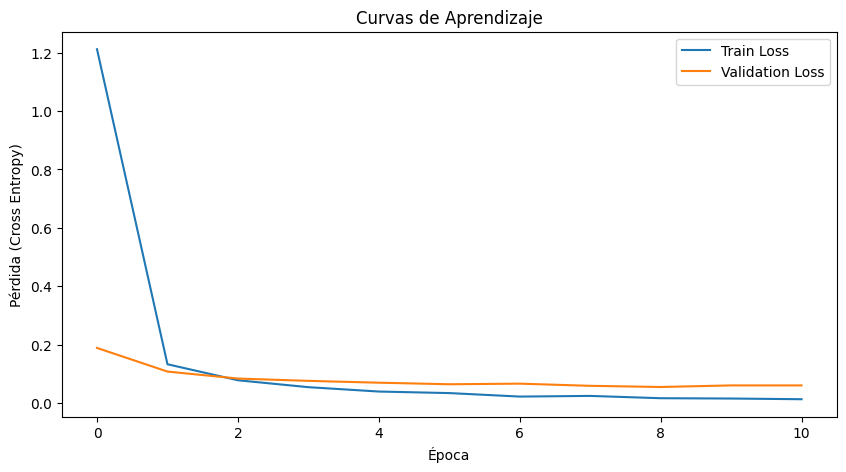

In [9]:
def get_model(num_classes):
    model = InceptionResnetV1(pretrained='vggface2', classify=True).to(device)
    for param in model.parameters():
        param.requires_grad = False
    
    model.logits = nn.Linear(512, num_classes).to(device)
    for param in model.logits.parameters():
        param.requires_grad = True
        
    return model

def train_con_early_stopping(model, train_loader, val_loader, max_epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.logits.parameters(), lr=0.001)
    early_stopping = EarlyStopping(patience=3, min_delta=0.01)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Train]"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validación
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch [{epoch+1}/{max_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print("🛑 Early stopping disparado. Deteniendo entrenamiento.")
            break
            
    # Graficar curvas de pérdida
    plt.figure(figsize=(10,5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Curvas de Aprendizaje')
    plt.xlabel('Época')
    plt.ylabel('Pérdida (Cross Entropy)')
    plt.legend()
    plt.show()
    
    return model

# Descomenta esto para entrenarlo
modelo_entrenado = train_con_early_stopping(get_model(num_classes), train_loader, val_loader, max_epochs=20)

In [ ]:
def extract_embeddings(modelo, loader):
    modelo.eval()
    embeddings = []
    etiquetas = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Extrayendo embeddings"):
            inputs = inputs.to(device)
            # Pasamos por el modelo (recordar que si usamos el entrenado, necesitamos el feature extractor)
            # InceptionResnetV1 devuelve los embeddings si classify=False, pero si lo cargamos
            # con classify=True, podemos ignorar el head accediendo a model.forward_impl o instanciando de nuevo
            out = modelo(inputs) 
            embeddings.append(out.cpu().numpy())
            etiquetas.append(labels.numpy())
            
    return np.vstack(embeddings), np.concatenate(etiquetas)

# 1. Extraemos vectores del modelo SIN entrenar
modelo_base = InceptionResnetV1(pretrained='vggface2', classify=False).to(device)
print("Evaluando modelo BASE (Zero-Shot)...")
emb_train_base, y_train_base = extract_embeddings(modelo_base, train_loader)
emb_val_base, y_val_base = extract_embeddings(modelo_base, val_loader)

knn_base = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn_base.fit(emb_train_base, y_train_base)
acc_base = accuracy_score(y_val_base, knn_base.predict(emb_val_base))
print(f"🏆 Accuracy Modelo BASE: {acc_base*100:.2f}%")

# 2. Extraer vectores del modelo ENTRENADO (Fine-Tuned)
# Carga tus pesos de "models/inception_resnet_lfw_finetuned.pth"

try:
    
    print("\nEvaluando modelo FINE-TUNED...")
    emb_train_ft, y_train_ft = extract_embeddings(modelo_entrenado, train_loader)
    emb_val_ft, y_val_ft = extract_embeddings(modelo_entrenado, val_loader)

    knn_ft = KNeighborsClassifier(n_neighbors=3, metric='cosine')
    knn_ft.fit(emb_train_ft, y_train_ft)
    acc_ft = accuracy_score(y_val_ft, knn_ft.predict(emb_val_ft))
    print(f"🏆 Accuracy Modelo FINE-TUNED: {acc_ft*100:.2f}%")
except Exception as e:
    print(f"No se pudo cargar el modelo fine-tuned: {e}")

Evaluando modelo BASE (Zero-Shot)...


Extrayendo embeddings: 100%|██████████| 19/19 [00:09<00:00,  1.99it/s]


🏆 Accuracy Modelo BASE: 99.50%
No se pudo cargar el modelo fine-tuned: [Errno 2] No such file or directory: 'models/inception_resnet_lfw_finetuned.pth'


In [ ]:
mtcnn = MTCNN(image_size=160, margin=20, device=device, post_process=True)

In [12]:
def generate_and_store_embeddings(lfw_data, mtcnn, store: PgVectorEmbeddingStore):
    print("Generando embeddings y guardando en PGVector...")
    
    # Cargamos el backbone SIN la capa de clasificación (classify=False) para sacar embeddings
    embedding_model = InceptionResnetV1(pretrained='vggface2', classify=False).to(device)
    embedding_model.eval()

    loop = tqdm(range(len(lfw_data.images)))
    for idx in loop:
        img_np = (lfw_data.images[idx] * 255).astype(np.uint8)
        label_id = lfw_data.target[idx]
        person_name = lfw_data.target_names[label_id]
        
        # Detectar
        face = mtcnn(img_np)
        if face is None:
            continue
            
        # Generar embedding (agregamos dimensión de batch)
        face = face.unsqueeze(0).to(device)
        with torch.no_grad():
            embedding = embedding_model(face).cpu().numpy().flatten()
            
        # Guardar en BD usando los schemas de tu proyecto
        record = EmbeddingRecord(
            id_imagen=str(uuid.uuid4()),
            embedding=embedding.tolist(),
            path=f"{person_name}_{idx}.jpg", # Como viene de sklearn no tenemos el path real
            etiqueta=person_name,
            metadata={"source": "LFW Sklearn"}
        )
        store.append(record)

In [13]:
generate_and_store_embeddings(lfw_data, mtcnn, store)

Generando embeddings y guardando en PGVector...


100%|██████████| 3023/3023 [05:56<00:00,  8.49it/s]


Calculando Curva ROC para el modelo BASE...


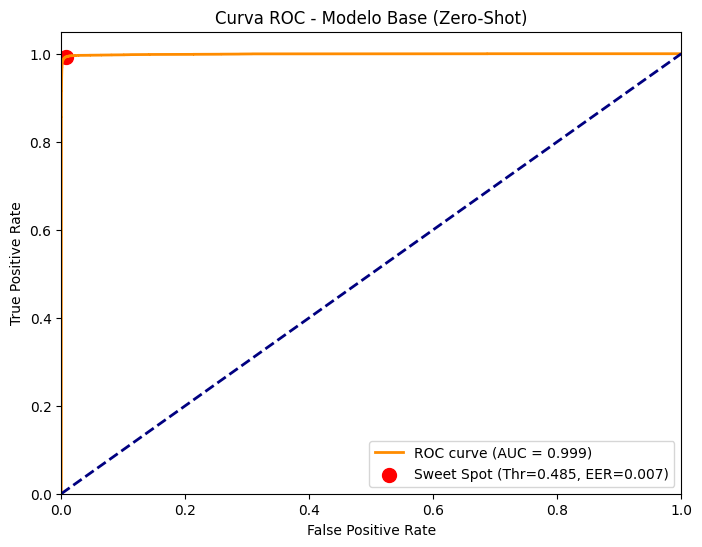

In [14]:
def plot_roc_curve(embeddings, labels, title="Curva ROC"):
    # Calculamos la matriz de similitud coseno completa
    dist_matrix = pairwise_distances(embeddings, metric='cosine')
    sim_matrix = 1 - dist_matrix # Similitud coseno (1 a -1)
    
    y_true = []
    y_scores = []
    
    n = len(labels)
    # Extraemos pares (solo la mitad superior de la matriz para no duplicar)
    for i in range(n):
        for j in range(i+1, n):
            is_same = int(labels[i] == labels[j])
            y_true.append(is_same)
            y_scores.append(sim_matrix[i, j])
            
    # Calculamos FPR, TPR y AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Encontrar el Sweet Spot (Umbral óptimo, EER - Equal Error Rate)
    # Buscamos el punto donde False Positive Rate y False Negative Rate (1-TPR) se cruzan
    fnr = 1 - tpr
    eer_threshold_idx = np.nanargmin(np.absolute((fnr - fpr)))
    opt_threshold = thresholds[eer_threshold_idx]
    eer = fpr[eer_threshold_idx]
    
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.scatter(fpr[eer_threshold_idx], tpr[eer_threshold_idx], color='red', s=100, label=f'Sweet Spot (Thr={opt_threshold:.3f}, EER={eer:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

# Graficar para el modelo Base
print("Calculando Curva ROC para el modelo BASE...")
plot_roc_curve(emb_val_base, y_val_base, title="Curva ROC - Modelo Base (Zero-Shot)")

# Graficar para el modelo Fine-Tuned
if 'emb_val_ft' in locals():
    print("Calculando Curva ROC para el modelo FINE-TUNED...")
    plot_roc_curve(emb_val_ft, y_val_ft, title="Curva ROC - Modelo Fine-Tuned")


In [15]:
def get_model(num_classes):
    # CRÍTICO: classify=True le dice a la red que pase por la capa 'logits'
    model = InceptionResnetV1(pretrained='vggface2', classify=True).to(device)
    for param in model.parameters():
        param.requires_grad = False
    
    # Reemplazamos el head para el entrenamiento
    model.logits = nn.Linear(512, num_classes).to(device)
    for param in model.logits.parameters():
        param.requires_grad = True
        
    return model